[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/astheeggeggs/testing_colab/blob/main/LDSC_Practical_2_Colab.ipynb)

# LDSC Practical 2 — Genetic Correlation (Colab version)

**MadhurBain Singh, Benjamin Neale**  
**March 5th, 2025**  
**Adapted from Andrew Grotzinger, March 2023**

This notebook is a Colab-friendly rewrite of the original R practical.
It assumes an **R runtime** in Colab.

**Before you start**
- Put the practical files in one public Google Drive folder, or upload them into `/content`.
- Make sure the folder contains the `EUR/` and `EAS/` directories used below.
- Run the setup cells from top to bottom.

## 1) Environment setup / required packages

This notebook uses an R runtime.
We install the packages needed for the practical from CRAN and GitHub.

Packages used here:
- `data.table`
- `dplyr`
- `remotes`
- `GenomicSEM`
- `corrplot`

In [ ]:
# System libraries that are often useful for R package installation in Colab
system("apt-get update -qq")
system("apt-get install -y -qq libcurl4-openssl-dev libxml2-dev libssl-dev")
system('python -m pip -q install gdown')


In [ ]:
system('gdown --folder https://drive.google.com/drive/folders/1DtztFjNBVYP6o72GCIwnUo7MyGjfURtx -O /content/LDSC_Practical_2')
system("tar -xzvf /content/LDSC_Practical_2/rg.tar.gz")
system("rm /content/LDSC_Practical_2/rg.tar.gz")

In [ ]:
# Install CRAN packages
install.packages(
  c("data.table", "dplyr", "remotes", "corrplot"),
  repos = "https://cloud.r-project.org"
)

# Install GenomicSEM from GitHub
remotes::install_github("GenomicSEM/GenomicSEM", upgrade = "never")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Installing 18 packages: R.methodsS3, iterators, R.oo, foreach, quadprog, numDeriv, pbivnorm, mnormt, gtools, proxy, mgsub, R.utils, splitstackshape, doParallel, lavaan, gdata, e1071, plyr

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpkkLImm/remotesc8355b0af24/GenomicSEM-GenomicSEM-123ec96/DESCRIPTION’ ... OK
* preparing ‘GenomicSEM’:
* checking DESCRIPTION meta-information ... OK
* excluding invalid files
Subdirectory 'man' contains invalid file names:
  ‘decisiontree.png’
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Omitted ‘LazyData’ from DESCRIPTION
* building ‘GenomicSEM_0.0.5.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



### Load packages

In [ ]:
library(data.table)
library(dplyr)
library(GenomicSEM)
library(corrplot)

sessionInfo()


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“replacing previous import ‘gdata::nobs’ by ‘lavaan::nobs’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::last’ by ‘data.table::last’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::first’ by ‘data.table::first’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::resample’ by ‘R.utils::resample’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::env’ by ‘R.utils::env’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘data.table::first’ by ‘dplyr::f

R version 4.6.0 (2026-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] corrplot_0.95     GenomicSEM_0.0.5  dplyr_1.2.1       data.table_1.18.4

loaded via a namespace (and not attached):
 [1] generics_0.1.4          class_7.3-23            gtools

## 2) Colab working directory and file helpers

The code below assumes that the practical files are available in `/content/LDSC_Practical_2`.
If you used the download cell above, that is where the files will be.

In [ ]:
root_dir <- "LDSC_Practical_2/final"

# Keep paths explicit rather than relying on setwd()
eur_dir <- file.path(root_dir, "EUR")
eas_dir <- file.path(root_dir, "EAS")

# Helper functions for cleaner file previews in notebooks
preview_text <- function(path, n = 10) {
  cat(readLines(path, n = n), sep = "\n")
  cat("\n")
}

preview_gz <- function(path, n = 10) {
  con <- gzfile(path, open = "rt")
  on.exit(close(con), add = TRUE)
  cat(readLines(con, n = n), sep = "\n")
  cat("\n")
}

count_lines <- function(path) {
  length(readLines(path, warn = FALSE))
}

count_gz_lines <- function(path) {
  con <- gzfile(path, open = "rt")
  on.exit(close(con), add = TRUE)
  length(readLines(con, warn = FALSE))
}

list.files(root_dir, recursive = TRUE)[1:min(20, length(list.files(root_dir, recursive = TRUE)))]

[1] "EAS/BMI_EAS_chr1.txt"                           
 [2] "EAS/BMI_Height_munge.log"                       
 [3] "EAS/BMI.sumstats.gz"                            
 [4] "EAS/BMI.sumstats.gz_Height.sumstats.gz_ldsc.log"
 [5] "EAS/eas_ldscores/1.l2.ldscore.gz"               
 [6] "EAS/eas_ldscores/1.l2.M"                        
 [7] "EAS/eas_ldscores/1.l2.M_5_50"                   
 [8] "EAS/eas_ldscores/10.l2.ldscore.gz"              
 [9] "EAS/eas_ldscores/10.l2.M"                       
[10] "EAS/eas_ldscores/10.l2.M_5_50"                  
[11] "EAS/eas_ldscores/11.l2.ldscore.gz"              
[12] "EAS/eas_ldscores/11.l2.M"                       
[13] "EAS/eas_ldscores/11.l2.M_5_50"                  
[14] "EAS/eas_ldscores/12.l2.ldscore.gz"              
[15] "EAS/eas_ldscores/12.l2.M"                       
[16] "EAS/eas_ldscores/12.l2.M_5_50"                  
[17] "EAS/eas_ldscores/13.l2.ldscore.gz"              
[18] "EAS/eas_ldscores/13.l2.M"                       
[19] "EAS/eas_ldscores/13.l2.M_5_50"                  
[20] "EAS/eas_ldscores/14.l2.ldscore.gz"

In this session, we are working with the R script LDSC_Practical2_GeneticCorrelation.R

We will perform three sets of bivariate linkage disequilibrium score regression (LDSC) analyses. Please work together as a group to help each other with the tasks.
European ancestry GWAS summary statistics for body mass index (BMI) and height data (continuous traits).
East Asian ancestry GWAS summary statistics for BMI and height data (continuous traits).
European ancestry GWAS summary statistics for Schizophrenia and Bipolar Disorder (binary traits).

Run the script lines 1 to 50.

Here, we have specified the directories and loaded the required R libraries.


The reference directory includes the HapMap3 (HM3) SNP IDs and their pre-computed LD scores.

Examine the HM3 SNP file using the code that you have already run.

How many SNPs are there in the HapMap3 reference file (w_hm3.snplist)?

Answer: There are 1,217,311 SNPs included in the HM3 reference file.



We will still restrict the LDSC analyses to the HapMap3 SNPs in this practical because we have the pre-computed LD scores for these SNPs only.



We may specify additional QC filters (imputation R2 [info_cutoff <- 0.9] and minor allele frequency [maf_cutoff  <- 0.01]), if the GWAS sum stats include information on these QC metrics.

We will drop the SNPs with imputation R2 (INFO) < 0.90 or MAF < 0.01.



Do both sum stats files have the sample size (N) information?

This is important, because if N is not included in the sum stats file, we need to find the appropriate N from a README file or the manuscript and specify in munge().

Answer: YES! The columns are conveniently named "N" in both files.

We can now perform munge.

Examine and run lines 51 - 75.

Which column is interpreted as the effect allele (A1) for Height?

Answer: The EFFECT_ALLELE column, which is the correct column.


How many SNPs were present in the raw sum stats file for Height?

Answer: There were 96,851 SNPs present in the raw sum stats file.

How many SNPs were dropped from Height sum stats because these are not present in the reference HapMap3 file?

Answer: 7,910 SNPs were dropped because these are not present in the reference HapMap3 file

How many SNPs were dropped from Height sum stats due to low imputation quality (i.e., INFO)?

Answer: None, as there was no INFO column in the raw dataset.

How many SNPs were dropped from Height sum stats due to low or missing MAF?

Answer: 0 SNP was dropped due to low or missing MAF.


Usually, there will be few HapMap3 SNPs with MAF < 0.01 - which is why no SNP was dropped here.

How many SNPs are left in the munged sum stats file from Height?

Answer: 88,941 SNPs are left in the munged sum stats file.

Now we are done munging the sum stats. Using the code below, perform LDSC analyses on the munged sum stats.

Examine and run lines 81 to 120.


What are the sample and population prevalences specified in ldsc()?

Answer: NA for both traits.

We are examining continuous traits here, so prevalence rates are not applicable!

Now, examine the log printed in the R console.
The log/output of bivariate LDSC has three main parts:
[1/3] LDSC analyses of BMI (h2_SNP)
[2/3] Cross-trait LDSC analyses of BMI and Height (r_g)
[3/3] LDSC analyses of Height (h2_SNP)


Is there evidence of significant confounding (population stratification) in the GWAS of either trait?

Answer: No.

Neither trait has LDSC intercepts significantly greater than 1.
BMI: 0.9355 (SE = 0.0803)
Height: 1.3365 (0.3003)


Is there evidence of shared confounding or sample overlap between BMI and Height GWASs?

Answer: No

The cross-trait LDSC intercept is not significantly greater than 0 [-0.0688 (SE = 0.0772)], suggesting no significant shared confounding (population stratification) or sample overlap.

What is the estimated genetic correlation of BMI and height?

Answer: -0.0272 (S.E. 0.0436)


Now, you may also make a heatmap showing the genetic correlation(s).

Run lines 130 - 185.
This provides you sample code for creating such heatmaps for manuscripts.

## Part 1: Continuous traits example in European ancestry

This section uses chromosome 1 summary statistics for BMI and height.

### HapMap3 SNPs

As before, we restrict the analyses to high-quality SNPs in the GWAS summary statistics that overlap with the pre-computed LD scores.

In [ ]:
hm3_eur <- file.path(eur_dir, "eur_w_ld_chr", "w_hm3.snplist")

# Take a look at the first few lines
preview_text(hm3_eur)

# Count the number of lines
cat("Number of lines in HM3 file:", count_lines(hm3_eur), "\n")

SNP	A1	A2
rs3094315	G	A
rs3131972	A	G
rs3131969	A	G
rs1048488	C	T
rs3115850	T	C
rs2286139	C	T
rs12562034	A	G
rs4040617	G	A
rs2980300	T	C

Number of lines in HM3 file: 1217312 


**Question:** How many SNPs are there in the HapMap3 reference file?

### Step 1: Munge the data

In [ ]:
# Look at the summary statistics files and their columns
preview_text(file.path(eur_dir, "GIANT_UKB_BMI_EUR_chr1.txt"))
preview_text(file.path(eur_dir, "Yengo_Height_EUR_chr1.txt"))

# For multivariate LDSC, specify a vector of file paths with GWAS summary statistics
files_eur <- c(
  file.path(eur_dir, "GIANT_UKB_BMI_EUR_chr1.txt"),
  file.path(eur_dir, "Yengo_Height_EUR_chr1.txt")
)

# Trait names should match the order of the file paths
trait_names_eur <- c("BMI_chr1", "Height_chr1")

# Quality filters
info.filter <- 0.9
maf.filter <- 0.01

munge(
  files = files_eur,
  hm3 = hm3_eur,
  trait.names = trait_names_eur,
  info.filter = info.filter,
  maf.filter = maf.filter
)

CHR	POS	SNP	A1	A2	BETA	SE	P	N	MAF
1	162736463	rs1000050	T	C	0.0027	0.0024	0.26	690227	0.145
1	157255396	rs1000073	A	G	7e-04	0.0018	0.7	688612	0.3942
1	95166832	rs1000075	T	C	-0.0011	0.0018	0.54	686026	0.3518
1	66857915	rs1000085	C	G	0.0034	0.0021	0.1	685310	0.2171
1	63432716	rs1000127	T	C	0.003	0.0019	0.12	679981	0.2951
1	205505477	rs1000312	A	G	0.004	0.0018	0.03	676991	0.348
1	15405489	rs1000313	A	G	3e-04	0.0021	0.9	692562	0.2097
1	15041242	rs1000348	C	G	5e-04	0.0018	0.78	688819	0.3787
1	209675578	rs1000352	T	C	7e-04	0.0031	0.81	690430	0.09021

RSID CHR POS EFFECT_ALLELE OTHER_ALLELE EFFECT_ALLELE_FREQ BETA SE P N MAF
rs12564807 1 734462 A G 0.893 0.0046569 0.011 0.672866 112953 0.107
rs3131972 1 752721 G A 0.84 0.000544089 0.00284 0.84811 615932 0.16
rs3131969 1 754182 G A 0.865 0.00133311 0.00185 0.470389 1100634 0.135
rs3131967 1 754334 C T 0.866 0.00142919 0.00185 0.440485 1095682 0.134
rs1048488 1 760912 T C 0.845 -0.00273203 0.00239 0.253228 842431 0.155
rs12562034 1 768448 A G 

### Step 2: Run LDSC

In [ ]:
# Examine the munged summary statistics
preview_gz(file.path(eur_dir, "BMI.sumstats.gz"))
preview_gz(file.path(eur_dir, "Height.sumstats.gz"))

traits_eur <- c(
  file.path(eur_dir, "BMI.sumstats.gz"),
  file.path(eur_dir, "Height.sumstats.gz")
)

ld_eur <- file.path(eur_dir, "eur_w_ld_chr")
wld_eur <- file.path(eur_dir, "eur_w_ld_chr")
sample.prev_eur <- c(NA, NA)
population.prev_eur <- c(NA, NA)
trait_names_ldsc_eur <- c("BMI", "Height")

LDSC_EUR <- ldsc(
  traits = traits_eur,
  sample.prev = sample.prev_eur,
  population.prev = population.prev_eur,
  ld = ld_eur,
  wld = wld_eur,
  trait.names = trait_names_ldsc_eur
)

save(LDSC_EUR, file = file.path(eur_dir, "LDSC_EUR.RData"))

SNP	N	Z	A1	A2
rs1000050	690227	-1.1263911290388	C	T
rs1000073	688612	0.385320466407568	A	G
rs1000313	692562	-0.125661346855074	G	A
rs1000352	690430	-0.240426031142308	C	T
rs1000370	692467	-1.92683657326391	T	G
rs1000417	690321	2.09692742916434	G	A
rs1000418	691995	2.21151780918668	G	A
rs1000476	675964	0.214701568001745	C	T
rs1000528	689369	0.201893479141851	C	T

SNP	N	Z	A1	A2
rs1000050	1594696	4.37925814781966	C	T
rs1000073	1596580	-0.413171455350674	A	G
rs1000283	1597326	6.05345010448693	A	G
rs1000313	1596497	-1.39770723748414	G	A
rs1000314	1596503	-1.29940493199304	G	A
rs1000352	1597369	-2.64064817265784	C	T
rs1000370	1597367	2.49028972255882	T	G
rs1000417	1597338	0.986181613812812	G	A
rs1000418	1597359	1.1598988279234	G	A

Multivariate ld-score regression of 2 traits (LDSC_Practical_2/final/EUR/BMI.sumstats.gz LDSC_Practical_2/final/EUR/Height.sumstats.gz) began at: 2026-05-24 16:22:41.057077
Reading in LD scores
Read in summary statistics [1/2] from: LDSC_Practical_2/final/EUR/BMI.

### Inspect the outputs

In [ ]:
# Genetic covariance matrix
LDSC_EUR$S

# Genetic correlation matrix
cov2cor(LDSC_EUR$S)

# Standard errors from the V matrix
k <- nrow(LDSC_EUR$S)
SE <- matrix(0, k, k)
SE[lower.tri(SE, diag = TRUE)] <- sqrt(diag(LDSC_EUR$V))
SE

# Z-statistics
Z <- LDSC_EUR$S / SE
Z

# P-values
P <- 2 * pnorm(Z, lower.tail = FALSE)
P

BMI,Height
0.209152227,-0.008009202
-0.008009202,0.415801445


BMI,Height
1.00000000,-0.02715908
-0.02715908,1.00000000


0.02100718,0.00000000
0.01285152,0.04476013


BMI,Height
9.9562243,-Inf
-0.6232103,9.289549


BMI,Height
2.368890e-23,2.000000e+00
1.466854e+00,1.549439e-20


### Optional: Create an rg heatmap

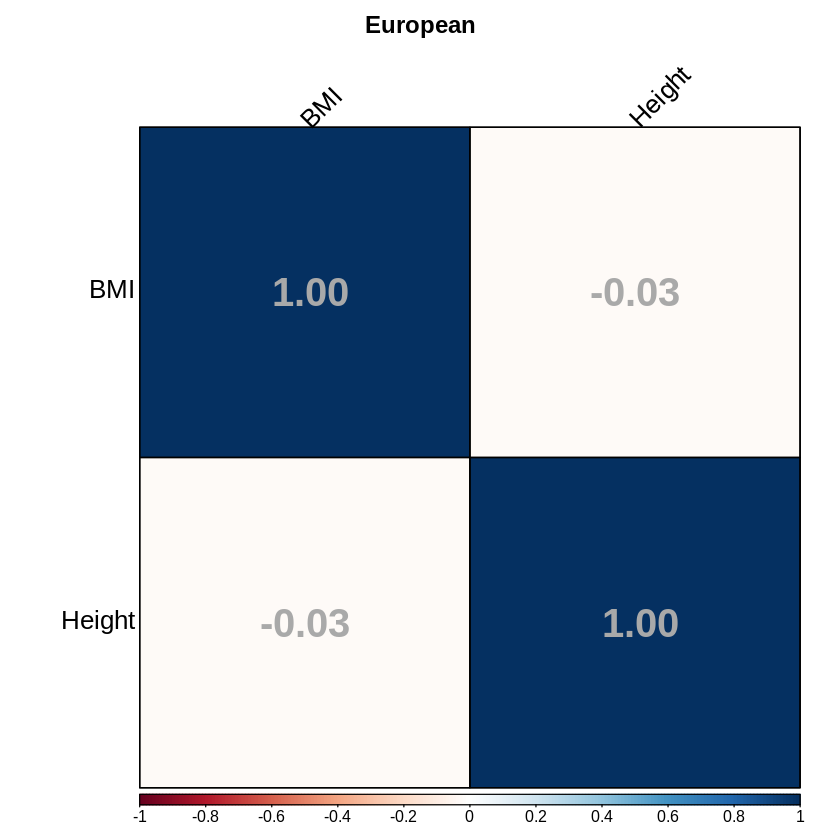

In [ ]:
rownames(LDSC_EUR$S) <- colnames(LDSC_EUR$S)

corrplot(
  corr = cov2cor(LDSC_EUR$S),
  method = "color",
  addCoef.col = "dark grey",
  add = FALSE,
  bg = "white",
  diag = TRUE,
  outline = TRUE,
  mar = c(0, 0, 2, 0),
  number.cex = 2,
  cl.pos = "b",
  cl.ratio = 0.125,
  cl.align.text = "l",
  cl.offset = 0.2,
  tl.srt = 45,
  tl.pos = "lt",
  tl.offset = 0.2,
  tl.col = "black",
  pch.col = "white",
  addgrid.col = "black",
  xpd = TRUE,
  tl.cex = 1.3,
  is.corr = TRUE,
  title = "European"
)

## Part 2: Continuous traits example in East Asian ancestry

The summary statistics and LD scores for this section are from East Asian ancestry.

Now, we can also perform similar bivariate LDSC analyses for BMI and height in East Asian ancestry.

As before, we start by examining if the sum stats files have the necessary columns.

Examine and run lines 185 - 200.

Do both sum stats files include information on N?

Answer: The BMI sum stats do not include N.

So, we'd have to specify N for BMI when we run munge() now.

Read and run lines 201 - 235.

Note that we are now using ancestrally matched LD scores computed in East Asian ancestry.

Ensure that the munge function interprets the columns correctly for both trait.

Which columns are interpreted as the effect allele (A1) in the two traits?

Answer: Here, the effect allele (A1) is ALLELE1 in the BMI sum stats and EFFECT_ALLELE in the Height sum stats.


Now, we can run LDSC analyses as before.

Examine and run lines 240 - 285.

The log will look similar to the analyses above, with three parts.
[1/3] LDSC analyses of BMI (h2_SNP)
[2/3] Cross-trait LDSC analyses of BMI and Height (r_g)
[3/3] LDSC analyses of Height (h2_SNP)


How do the SNP heritability estimates of BMI and height differ between East Asian and European ancestry samples?

Answer
The h2_SNP estimates of both BMI and height are lower in the East Asian ancestry sample than the European ancestry sample:
BMI: 0.14 in EAS; 0.21 in EUR
Height: 0.24 in EAS; 0.42 in EUR



We may also make a similar heatmap for genetic correlation in EAS.
Examine and run lines 286 - 335.

What is the genetic correlation between BMI and height in EAS, and its S.E.?


Answer:  The genetic correlation between BMI and height in the EAS ancestry sample is -0.129 (S.E. = 0.077).

In [ ]:
# Look at the files
preview_text(file.path(eas_dir, "BMI_EAS_chr1.txt"))
preview_text(file.path(eas_dir, "Yengo_Height_EAS_chr1.txt"))

files_eas <- c(
  file.path(eas_dir, "BMI_EAS_chr1.txt"),
  file.path(eas_dir, "Yengo_Height_EAS_chr1.txt")
)

hm3_eas <- file.path(eas_dir, "eas_ldscores", "w_hm3.snplist")
preview_text(hm3_eas)
cat("Number of lines in EAS HM3 file:", count_lines(hm3_eas), "\n")

trait_names_eas <- c("BMI", "Height")
N_eas <- c(163835, NA)
info.filter <- 0.9
maf.filter <- 0.01

munge(
  files = files_eas,
  hm3 = hm3_eas,
  trait.names = trait_names_eas,
  N = N_eas,
  info.filter = info.filter,
  maf.filter = maf.filter
)

SNP CHR BP ALLELE1 ALLELE0 INFO MAF BETA SE PVAL
rs28544273 1 751343 T A 0.902227 0.148008 0.000594251 0.00468681 0.9
rs28527770 1 751756 T C 0.907138 0.147545 0.000570884 0.00467584 0.9
rs3094315 1 752566 G A 0.99888 0.157581 -0.000588948 0.00433112 0.89
rs3131971 1 752894 T C 0.935874 0.150678 -0.000526474 0.00455903 0.91
rs3115860 1 753405 C A 0.913917 0.148833 -0.000417782 0.00464283 0.93
rs3131970 1 753425 T C 0.91823 0.149492 -0.000409525 0.00462351 0.93
1:756285:ATCCACCCTGTCTACACTACCTGCTTGTCCAGCAGG:A 1 756285 ATCCACCCTGTCTACACTACCTGCTTGTCCAGCAGG A 0.850959 0.141346 0.00106927 0.0049377 0.83
rs10157329 1 759293 T A 0.771496 0.123166 -0.00111287 0.00550004 0.84
rs3115852 1 759700 T C 0.928757 0.154489 -0.000723213 0.00454467 0.87

RSID CHR POS EFFECT_ALLELE OTHER_ALLELE EFFECT_ALLELE_FREQ BETA SE P N MAF
rs3131972 1 752721 G A 0.833 0.00210069 0.00438 0.63153 239087 0.167
rs3131969 1 754182 G A 0.829 0.00287384 0.0048 0.549178 239087 0.171
rs3131967 1 754334 C T 0.833 0.00220745 0

In [ ]:
preview_gz(file.path(eas_dir, "BMI.sumstats.gz"))
preview_gz(file.path(eas_dir, "Height.sumstats.gz"))

traits_eas <- c(
  file.path(eas_dir, "BMI.sumstats.gz"),
  file.path(eas_dir, "Height.sumstats.gz")
)

ld_eas <- file.path(eas_dir, "eas_ldscores")
wld_eas <- file.path(eas_dir, "eas_ldscores")
sample.prev_eas <- c(NA, NA)
population.prev_eas <- c(NA, NA)
trait_names_ldsc_eas <- c("BMI", "Height")

LDSC_EAS <- ldsc(
  traits = traits_eas,
  sample.prev = sample.prev_eas,
  population.prev = population.prev_eas,
  ld = ld_eas,
  wld = wld_eas,
  trait.names = trait_names_ldsc_eas
)

save(LDSC_EAS, file = file.path(eas_dir, "LDSC_EAS.RData"))

SNP	N	Z	A1	A2
rs1000050	163835	-1.91103564754912	C	T
rs1000073	163835	0.495850347347453	A	G
rs1000283	163835	1.64485362695147	A	G
rs1000313	163835	0.48172684958473	G	A
rs1000314	163835	0.841621233572914	G	A
rs1000352	163835	0.823893630338558	C	T
rs1000370	163835	-0.0627067779432138	T	G
rs1000417	163835	0.358458793251194	G	A
rs1000418	163835	0.2533471031358	G	A

SNP	N	Z	A1	A2
rs1000050	264725	3.69067358263067	C	T
rs1000073	264725	-1.05010900285593	A	G
rs1000283	264725	3.43118437494083	A	G
rs1000313	264725	1.29587950855942	G	A
rs1000314	260044	1.49433913969481	G	A
rs1000352	264724	-3.01663900380985	C	T
rs1000370	262938	-1.12352638771273	T	G
rs1000417	264725	1.25297446439076	G	A
rs1000418	264724	1.62542045658011	G	A

Multivariate ld-score regression of 2 traits (LDSC_Practical_2/final/EAS/BMI.sumstats.gz LDSC_Practical_2/final/EAS/Height.sumstats.gz) began at: 2026-05-24 16:24:14.793428
Reading in LD scores
Read in summary statistics [1/2] from: LDSC_Practical_2/final/EAS/BMI.sumstats.gz


In [ ]:
# Genetic covariance matrix
LDSC_EAS$S

# Compare with EUR if needed
load(file.path(eur_dir, "LDSC_EUR.RData"))
LDSC_EUR$S

# Genetic correlation matrix
cov2cor(LDSC_EAS$S)

# Standard errors
k <- nrow(LDSC_EAS$S)
SE <- matrix(0, k, k)
SE[lower.tri(SE, diag = TRUE)] <- sqrt(diag(LDSC_EAS$V))
SE

# Z-statistics
Z <- LDSC_EAS$S / SE
Z

# P-values
P <- 2 * pnorm(Z, lower.tail = FALSE)
P

BMI,Height
0.1430809,-0.0239407
-0.0239407,0.2414167


BMI,Height
0.209152227,-0.008009202
-0.008009202,0.415801445


BMI,Height
1.0000000,-0.1288138
-0.1288138,1.0000000


0.01979010,0.00000000
0.01431529,0.03252978


BMI,Height
7.229925,-Inf
-1.672386,7.421406


BMI,Height
4.832614e-13,2.000000e+00
1.905552e+00,1.158835e-13


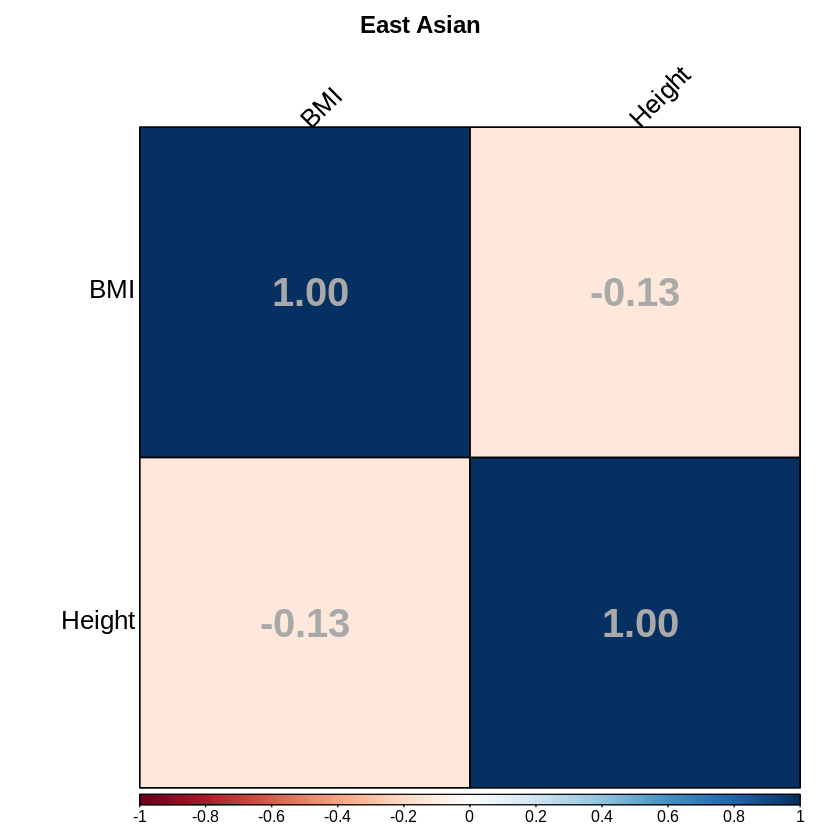

In [ ]:
rownames(LDSC_EAS$S) <- colnames(LDSC_EAS$S)

corrplot(
  corr = cov2cor(LDSC_EAS$S),
  method = "color",
  addCoef.col = "dark grey",
  add = FALSE,
  bg = "white",
  diag = TRUE,
  outline = TRUE,
  mar = c(0, 0, 2, 0),
  number.cex = 2,
  cl.pos = "b",
  cl.ratio = 0.125,
  cl.align.text = "l",
  cl.offset = 0.2,
  tl.srt = 45,
  tl.pos = "lt",
  tl.offset = 0.2,
  tl.col = "black",
  pch.col = "white",
  addgrid.col = "black",
  xpd = TRUE,
  tl.cex = 1.3,
  is.corr = TRUE,
  title = "East Asian"
)

## Part 3: Binary (case/control) traits example in European ancestry

Now, we will perform bivariate LDSC analyses for Schizophrenia (SCZ) and Bipolar Disorder (BIP) in European ancestry.

As before, we will first examine the columns in the GWAS sum stats file.

Examine and run lines 340 - 350.

Do the sum stats have information on the sample size? Is it raw N or the effective N?

Answer: SCZ sum stats include the effective N (NEFF). BIP sum stats include NEFFDIV2, which is half of the effective N.


Note that munge() can usually recognize these different types of N and interpret them correctly, such that it will multiply NEFFDIV2 by 2 to obtain the effective N. However, we must verify in the munge log that it is doing so.

Now, we can run lines 351 - 385.

How does munge() calculate the effective sample size for BIP sum stats?

Answer: For BIP, Neff is calculated by doubling NEFFDIV2.

If munge() does not identify the column correctly or doesn't double NEFFDIV2, you'd manually create a new column (NEFF = 2*NEFFDIV2) in the raw sum stats file and rerun munge().

Now, examine and run the lines 390 - 410.

Note that we need to specify the sample prevalence and population prevalence to obtain liability-scale estimates for binary traits.

The population prevalences of SCZ and BIP (0.01 and 0.02, respectively) are obtained from published epidemiological studies.

Question: What is the "sample prevalence" when we use the effective N (rather than the actual N, which is the sum of N_cases and N_controls)?

Answer: Effective_N implies sample_prevalence = 0.5.

Now, run ldsc() using lines 410 - 430, and examine the log/output.

LDSC will first report the observed-scale estimates, then the liability-scale estimates, and finally, the genetic correlation(s).

Question: What are the (univariate) LDSC intercepts and Attentuation Ratios of SCZ and BIP? Do these suggest residual population stratification in the GWAS?

Answer:
SCZ:  LDSC intercept = 1.1072 (S.E. = 0.0523). Attenutation Ratio = 0.0896 (S.E. = 0.0437)

BIP: LDSC intercept = 1.0032 (S.E. = 0.0349). Attenuation Ratio = 0.005 (S.E. =0.055)

Though SCZ sum stats show an LDSC intercept slightly >1, the attention ratio 0.09 suggests little population stratification in the GWAS.
Note that if N is very large, the LDSC intercept (N*a + 1) may become significantly >1 even with minimal confounding, a.

For BIP, the intercept and attenuation ratio show no sign of population stratification.


Question: What is the cross-trait LDSC intercept? What does it tell us about potential shared confounding between SCZ and BIP or sample overlap?

Answer: Cross-trait LDSC intercept = 0.1945 (S.E. = 0.0315).

This suggests likely sample overlap (e.g., overlapping controls for SCZ and BIP)

There could also be some shared residual population stratification between the two GWASs.
Note that the genetic covariance and correlation are estimated after accounting for these factors (sample overlap or shared confounding).


What is the liability-scale genetic covariance between SCZ and BIP? What is their genetic correlation?

Answer:
Genetic covariance (liability-scale) = 0.1511 (S.E. = 0.0168)
Genetic correlation = 0.7276 (S.E. = 0.0809)


Finally, we may now create a heatmap for this genetic correlation.
Examine and run lines 431 - 480.

In [ ]:
# Files
preview_text(file.path(eur_dir, "SCZ_chr1.txt"))
preview_text(file.path(eur_dir, "BIP_chr1.txt"))

files_bin <- c(
  file.path(eur_dir, "SCZ_chr1.txt"),
  file.path(eur_dir, "BIP_chr1.txt")
)

hm3_bin <- file.path(eur_dir, "eur_w_ld_chr", "w_hm3.snplist")
trait_names_bin <- c("SCZ", "BIP")
N_bin <- c(NA, NA)
info.filter <- 0.9
maf.filter <- 0.01

munge(
  files = files_bin,
  hm3 = hm3_bin,
  trait.names = trait_names_bin,
  N = N_bin,
  info.filter = info.filter,
  maf.filter = maf.filter
)

"CHROM" "ID" "POS" "A1" "A2" "FCAS" "FCON" "IMPINFO" "BETA" "SE" "PVAL" "NCAS" "NCON" "NEFF"
"229952" 1 "rs12034030" 68677760 "C" "T" 0.824 0.824 0.983 0.0021975835434872 0.0114 0.8488 53386 77258 117498.26
"229953" 1 "rs114605216" 69228887 "T" "C" 0.957 0.957 0.831 -0.0166986496230515 0.0233 0.4726 53386 77258 117498.26
"229954" 1 "rs10889564" 66053488 "C" "A" 0.721 0.72 0.996 -0.00950503001430495 0.0096 0.3246 53386 77258 117498.26
"229955" 1 "rs56235896" 61957893 "G" "T" 0.954 0.956 0.873 -0.0231969816042026 0.0224 0.3007 53386 77258 117498.26
"229956" 1 "rs12079616" 65989069 "A" "G" 0.976 0.977 0.991 -0.0332982854015147 0.029 0.2498 52841 75249 115800.62
"229957" 1 "rs78832141" 66660527 "A" "G" 0.98 0.98 0.968 0.0318958749835631 0.0334 0.3403 47703 66307 104023.56
"229958" 1 "rs12087596" 69423415 "C" "T" 0.104 0.102 0.996 0.0154992634469238 0.0142 0.2763 53386 77258 117498.26
"229959" 1 "rs12117388" 63119256 "T" "C" 0.83 0.827 0.99 0.00720398884850252 0.0115 0.5314 53386 77258 1174

In [ ]:
preview_gz(file.path(eur_dir, "SCZ.sumstats.gz"))
preview_gz(file.path(eur_dir, "BIP.sumstats.gz"))

traits_bin <- c(
  file.path(eur_dir, "SCZ.sumstats.gz"),
  file.path(eur_dir, "BIP.sumstats.gz")
)

ld_bin <- file.path(eur_dir, "eur_w_ld_chr")
wld_bin <- file.path(eur_dir, "eur_w_ld_chr")
sample.prev_bin <- c(0.5, 0.5)
population.prev_bin <- c(0.01, 0.02)
trait_names_ldsc_bin <- c("SCZ", "BIP")

LDSC_SCZ_BIP <- ldsc(
  traits = traits_bin,
  sample.prev = sample.prev_bin,
  population.prev = population.prev_bin,
  ld = ld_bin,
  wld = wld_bin,
  trait.names = trait_names_ldsc_bin
)

save(LDSC_SCZ_BIP, file = file.path(eur_dir, "LDSC_SCZ_BIP.RData"))

SNP	N	Z	A1	A2
rs1000050	117498.26	0.144127233511731	C	T
rs1000073	117498.26	-0.194735524167608	A	G
rs1000283	117498.26	-0.504514322598141	A	G
rs1000313	117498.26	1.19624747320143	G	A
rs1000314	117498.26	1.38386433224291	G	A
rs1000352	117498.26	2.49095570977309	C	T
rs1000370	117498.26	2.8957115090729	T	G
rs1000417	117498.26	-1.01858505993478	G	A
rs1000418	117498.26	-1.00250448812685	G	A

SNP	N	Z	A1	A2
rs1000050	101962.96	-1.08912220295691	C	T
rs1000073	101962.96	-1.22413845894589	A	G
rs1000283	101962.96	-3.31146152952416	A	G
rs1000313	101962.96	-0.693333953293917	G	A
rs1000314	101962.96	-0.493725576061732	G	A
rs1000352	101962.96	1.71230758284085	C	T
rs1000370	101962.96	0.552800538105071	T	G
rs1000417	101962.96	-0.893106765991927	G	A
rs1000418	101962.96	-0.937697284007606	G	A

Multivariate ld-score regression of 2 traits (LDSC_Practical_2/final/EUR/SCZ.sumstats.gz LDSC_Practical_2/final/EUR/BIP.sumstats.gz) began at: 2026-05-24 16:25:25.743754
Reading in LD scores
Read in summary statist

In [ ]:
# Genetic covariance matrix
LDSC_SCZ_BIP$S

# Genetic correlation matrix
cov2cor(LDSC_SCZ_BIP$S)

# Standard errors
k <- nrow(LDSC_SCZ_BIP$S)
SE <- matrix(0, k, k)
SE[lower.tri(SE, diag = TRUE)] <- sqrt(diag(LDSC_SCZ_BIP$V))
SE

# Z-statistics
Z <- LDSC_SCZ_BIP$S / SE
Z

# P-values
P <- 2 * pnorm(Z, lower.tail = FALSE)
P

SCZ,BIP
0.2230820,0.1511239
0.1511239,0.1933812


SCZ,BIP
1.0000000,0.7276018
0.7276018,1.0000000


0.02829856,0.00000000
0.01680296,0.01976867


SCZ,BIP
7.883154,Inf
8.993883,9.782206


SCZ,BIP
3.192182e-15,0.000000e+00
2.386472e-19,1.342521e-22


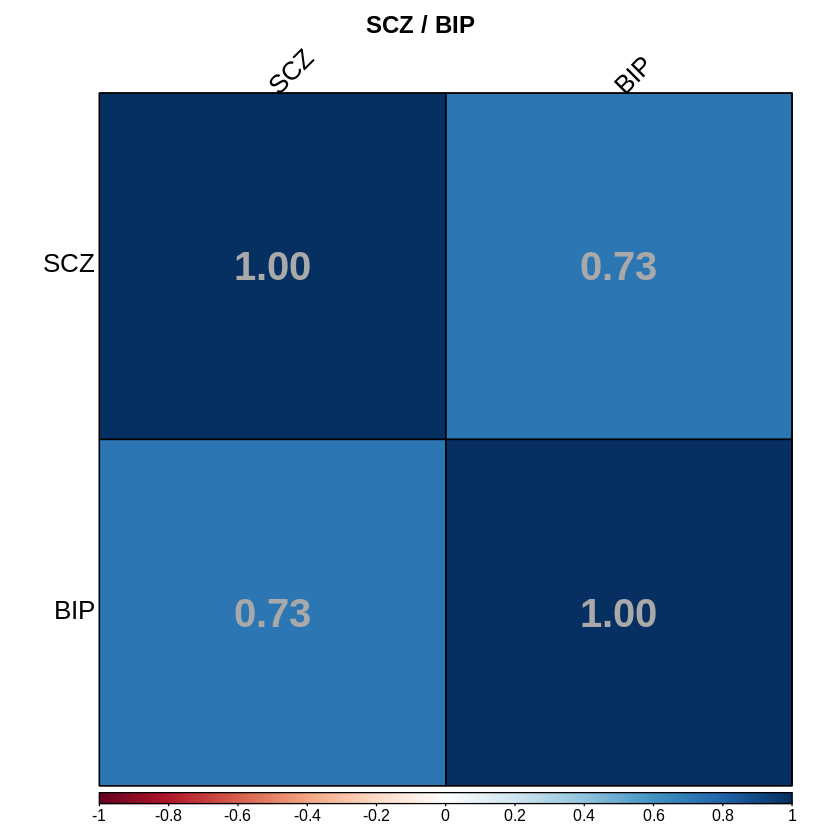

In [ ]:
rownames(LDSC_SCZ_BIP$S) <- colnames(LDSC_SCZ_BIP$S)

corrplot(
  corr = cov2cor(LDSC_SCZ_BIP$S),
  method = "color",
  addCoef.col = "dark grey",
  add = FALSE,
  bg = "white",
  diag = TRUE,
  outline = TRUE,
  mar = c(0, 0, 2, 0),
  number.cex = 2,
  cl.pos = "b",
  cl.ratio = 0.125,
  cl.align.text = "l",
  cl.offset = 0.2,
  tl.srt = 45,
  tl.pos = "lt",
  tl.offset = 0.2,
  tl.col = "black",
  pch.col = "white",
  addgrid.col = "black",
  xpd = TRUE,
  tl.cex = 1.3,
  is.corr = TRUE,
  title = "SCZ / BIP"
)

## End

You have now run the Colab version of Practical 2 for genetic correlation.